# 05 · Profit scenarios (Tier 2)

**Question.** If an operator puts one new public charger in a zone, does it earn back its capital,
and how wide is the range?

**Unit.** One charger of a given type (AC 22 kW post, DC 50 kW, DC 150 kW) in each of the 83 scored
municipalities (≥ 5,000 residents), at steady state after ramp-up. EUR, excluding VAT.

**Chain.** `zone score → utilization → kWh sold (capped by local resident demand) → revenue − fees −
electricity − fixed power charge − opex → NPV over the asset life → annual-equivalent margin`.
All logic lives in `profit_model.py` so notebook 06 reuses it.

Two kinds of range are reported:

* **Low / base / high** — every assumption set to its pessimistic, central or optimistic value
  together. These are *bounds*: all-pessimistic at once is unlikely, and so is all-optimistic.
* **Monte Carlo P10 / P50 / P90** — each assumption drawn independently from a triangular
  distribution (low, base, high). This is the more honest range, and `p_profitable` is the share
  of draws where the charger clears its cost of capital.

Inputs: `data/processed/zone_scores.csv` (notebook 04). Nothing from the two oversized raw files
(`ine_adrh_renta_31097.csv`, the OSM `.pbf`) is needed here: both were consumed upstream.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from profit_model import ASSUMPTIONS, CHARGER_TYPES, evaluate, params_for, sample_params  # noqa: E402

PROC, MAPS = ROOT / "data" / "processed", ROOT / "maps"
MAPS.mkdir(exist_ok=True)
pd.set_option("display.width", 200, "display.max_columns", 30)

# Chart tokens (reference palette, light mode)
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e0", "#fcfcfb"
BLUE, ORANGE, AQUA, RED, GRAY_MID = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#f0efec"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

## 1 Assumptions made

Ordered pessimistic to optimistic for the operator. Utilization is the biggest unknown: there is
no public session data, so it is a scenario input, and notebook 06 measures how much it matters.

Each row also records its provenance (`basis`, `source`, `source_url` in
`profit_assumptions.csv`): **cited** = read directly from the linked source, **derived** = computed
or adjusted from a cited figure, **judgement** = no source yet. Only selling prices are cited
directly; capex is derived from a 2019 US study and the fixed power charge is unsourced, so those
two are the first to replace with primary data.

In [2]:
ASSUMPTIONS.to_csv(PROC / "profit_assumptions.csv", index=False)
print(ASSUMPTIONS.basis.value_counts().to_string(), "\n")
ASSUMPTIONS[["param", "charger", "low", "base", "high", "unit", "basis"]]

basis
judgement    16
derived       7
cited         3 



,param,charger,low,base,high,unit,basis
0,util,AC22,0.08,0.12,0.18,share of hours plugged in,judgement
1,util,DC50,0.04,0.07,0.11,share of hours charging,derived
2,util,DC150,0.04,0.07,0.11,share of hours charging,derived
3,avg_kw,AC22,5.00,6.50,8.00,kW,judgement
4,avg_kw,DC50,30.00,36.00,42.00,kW,judgement
5,avg_kw,DC150,55.00,70.00,85.00,kW,judgement
6,price,AC22,0.39,0.45,0.52,EUR/kWh incl. VAT,cited
7,price,DC50,0.45,0.52,0.59,EUR/kWh incl. VAT,cited
8,price,DC150,0.52,0.59,0.69,EUR/kWh incl. VAT,cited
9,capex,AC22,14000.00,10000.00,7000.00,EUR per charger,derived


**How the score becomes utilization.** `utilization = base_util × m(score)`, with
`m = 1 + e·(score − 50)/50` and `e = 0.5` in the base case: a score-100 zone gets 1.5× the typical
utilization, a score-0 zone 0.5×. The score was built from percentiles of undersupply and demand,
so this is a deliberately simple, monotone mapping, not an estimate. Its slope is a tornado
variable in 06.

**Demand cap.** A charger cannot sell more than `capture × resident EVs × kWh/EV × public share`.
This only binds in small municipalities and ignores through-traffic (conservative for sites on
motorways).

In [3]:
zones = pd.read_csv(PROC / "zone_scores.csv")
elig = zones[zones.eligible].sort_values("rank").reset_index(drop=True)
print(f"{len(elig)} scored zones")

rows = []
for ct in CHARGER_TYPES:
    for case in ["low", "base", "high"]:
        r = evaluate(elig.score.values, elig.ev_resident_est.values, ct, params_for(ct, case))
        r.insert(0, "case", case)
        r.insert(0, "charger", ct)
        r.insert(0, "rank", elig["rank"].values)
        r.insert(0, "name", elig.name.values)
        r.insert(0, "ine_code", elig.ine_code.values)
        rows.append(r)
det = pd.concat(rows, ignore_index=True)
det.to_csv(PROC / "profit_scenarios_long.csv", index=False)

summary = (det.assign(profitable=det.margin > 0)
              .groupby(["charger", "case"])
              .agg(zones_profitable=("profitable", "sum"),
                   median_margin=("margin", "median"),
                   best_margin=("margin", "max"),
                   breakeven_util=("breakeven_util", "first"),
                   median_util=("utilization", "median"))
              .reindex(["low", "base", "high"], level=1).round(3))
summary

83 scored zones


zones_profitable  median_margin  best_margin  breakeven_util  median_util
charger case                                                                           
AC22    low                  0      -4711.456    -4586.991           0.970        0.076
        base                 0      -1624.960     -635.484           0.225        0.109
        high                81       3464.981     8665.237           0.049        0.156
DC150   low                  0     -39416.302   -37813.466           0.424        0.034
        base                 0     -14156.605    -3383.810           0.120        0.057
        high                83      30949.244    81616.114           0.027        0.090
DC50    low                  0     -16428.591   -15909.330           0.431        0.038
        base                 0      -5642.614    -1679.889           0.123        0.064
        high                81      13120.275    32615.279           0.030        0.095

**Reading the deterministic cases.** In the base case **no zone clears break-even** for any charger
type; in the all-optimistic case almost every zone does. The answer is decided by the assumptions,
not by location. The rest of this notebook asks how close the best zones are, and how likely they
are to clear it once the assumptions are allowed to vary independently.

## 2 · Monte Carlo ranges per zone

4,000 draws per charger type. The **same draws** are used for every zone (common random numbers),
so differences between zones reflect the zones, not sampling noise.

In [4]:
N = 4000
rng = np.random.default_rng(2026)
mc_rows, mc_draws = [], {}
for ct in CHARGER_TYPES:
    ps = sample_params(ct, N, rng)
    M = np.empty((len(elig), N))
    for i, z in elig.iterrows():
        M[i] = evaluate(z.score, z.ev_resident_est, ct, ps).margin.values
    mc_draws[ct] = (ps, M)
    q = np.quantile(M, [0.1, 0.5, 0.9], axis=1)
    mc_rows.append(pd.DataFrame({
        "ine_code": elig.ine_code, "charger": ct,
        "mc_p10": q[0], "mc_p50": q[1], "mc_p90": q[2],
        "p_profitable": (M > 0).mean(axis=1),
    }))
mc = pd.concat(mc_rows, ignore_index=True)

## 3 · One table per zone

For each zone: the best charger type, its low/base/high margins, MC range, probability of clearing
the cost of capital, and the utilization gap (break-even minus expected).

"Best" = highest `p_profitable`, with margin per euro of capex as the tie-break. Ranking by
absolute base margin would always pick the AC post, simply because a €10k asset loses fewer euros
than a €110k one: that is a statement about size, not about the quality of the investment.

In [5]:
wide = det.pivot_table(index=["ine_code", "charger"], columns="case",
                       values=["margin", "utilization", "energy_mwh", "revenue", "ebitda",
                               "payback_years", "breakeven_util", "breakeven_sessions_day",
                               "demand_capped"],
                       aggfunc="first")
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index().merge(mc, on=["ine_code", "charger"])
wide["util_gap_base"] = wide.breakeven_util_base - wide.utilization_base
capex_base = {ct: params_for(ct)["capex"] for ct in CHARGER_TYPES}
wide["margin_per_eur_capex_base"] = wide.margin_base / wide.charger.map(capex_base)

best = (wide.sort_values(["p_profitable", "margin_per_eur_capex_base"], ascending=False)
            .drop_duplicates("ine_code")
            .rename(columns=lambda c: c if c == "ine_code" else f"best_{c}"))
dc150 = wide[wide.charger == "DC150"].drop(columns="charger").add_prefix("dc150_").rename(
    columns={"dc150_ine_code": "ine_code"})

profit = (elig[["ine_code", "name", "population", "score", "rank", "top20_in_scenarios",
                "ev_resident_est", "public_points", "evs_per_public_point", "fleet_domicile_flag"]]
          .merge(best, on="ine_code").merge(dc150, on="ine_code"))
profit.to_csv(PROC / "profit_zones.csv", index=False)

cols = ["rank", "name", "score", "best_charger", "best_margin_low", "best_margin_base",
        "best_margin_high", "best_mc_p10", "best_mc_p50", "best_mc_p90", "best_p_profitable",
        "best_utilization_base", "best_breakeven_util_base"]
top20 = profit[profit["rank"] <= 20][cols].round(
    {"score": 1, "best_utilization_base": 3, "best_breakeven_util_base": 3, "best_p_profitable": 2})
for c in ["best_margin_low", "best_margin_base", "best_margin_high",
          "best_mc_p10", "best_mc_p50", "best_mc_p90"]:
    top20[c] = top20[c].round(-2).astype(int)
top20

,rank,name,score,best_charger,best_margin_low,best_margin_base,best_margin_high,best_mc_p10,best_mc_p50,best_mc_p90,best_p_profitable,best_utilization_base,best_breakeven_util_base
0,1.0,San Fernando de Henares,100.0,DC150,-37800,-3400,81600,-9900,-2000,7600,0.39,0.105,0.120
1,2.0,Boadilla del Monte,95.8,DC150,-37900,-4000,78200,-10300,-2600,6600,0.35,0.102,0.120
2,3.0,Pozuelo de Alarcón,90.4,DC150,-38000,-4900,73800,-10900,-3500,5500,0.30,0.098,0.120
3,4.0,Alpedrete,86.8,DC50,-16000,-2600,28200,-5000,-2000,1300,0.21,0.096,0.123
4,5.0,Villaviciosa de Odón,78.6,DC150,-38200,-6700,64200,-12200,-5300,2900,0.20,0.090,0.120
5,6.0,Humanes de Madrid,78.2,DC50,-16100,-3100,25400,-5400,-2600,600,0.15,0.090,0.123
6,7.0,Madrid,78.1,DC150,-38300,-6800,63700,-12300,-5400,2800,0.19,0.090,0.120
7,8.0,Paracuellos de Jarama,77.3,DC150,-38300,-6900,63100,-12400,-5500,2600,0.19,0.089,0.120
8,9.0,Galapagar,77.1,DC150,-38300,-7000,63000,-12400,-5500,2600,0.19,0.089,0.120
9,10.0,Parla,76.3,DC150,-38300,-7100,62300,-12500,-5600,2400,0.18,0.088,0.120


In [6]:
print(profit.best_charger.value_counts(), "\n")
print("Zones with P(profitable) >= 50% (best type):", (profit.best_p_profitable >= 0.5).sum())
print("Zones with P(profitable) >= 33% (best type):", (profit.best_p_profitable >= 1 / 3).sum())
print("Spearman(score, P(profitable) DC150):",
      round(profit[["score", "dc150_p_profitable"]].corr("spearman").iloc[0, 1], 3))
print("Zones demand-capped (DC150 base):", int(profit.dc150_demand_capped_base.sum()))

best_charger
DC50     44
DC150    33
AC22      6
Name: count, dtype: int64 

Zones with P(profitable) >= 50% (best type): 0
Zones with P(profitable) >= 33% (best type): 2
Spearman(score, P(profitable) DC150): 0.813
Zones demand-capped (DC150 base): 34


## 4 · Chart: margin range for the top-20 zones (DC 150 kW)

One charger type for comparability. Thick bar = Monte Carlo P10–P90, dot = P50, thin whisker =
all-pessimistic to all-optimistic bounds, tick = base case.

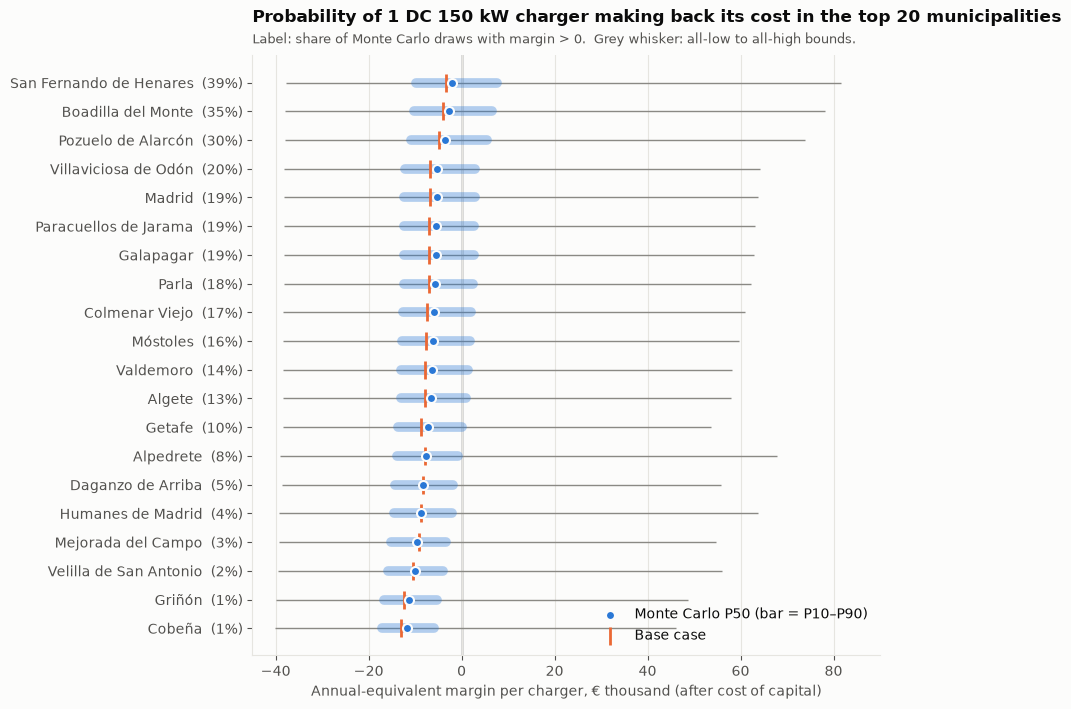

In [16]:
t = profit[profit["rank"] <= 20].sort_values("dc150_mc_p50")
y = np.arange(len(t))
fig, ax = plt.subplots(figsize=(9, 7.2))
ax.axvline(0, color=INK2, lw=1, zorder=1)
ax.hlines(y, t.dc150_margin_low / 1e3, t.dc150_margin_high / 1e3, color=MUTED, lw=1, zorder=2)
ax.hlines(y, t.dc150_mc_p10 / 1e3, t.dc150_mc_p90 / 1e3, color=BLUE, lw=7, alpha=0.35,
          capstyle="round", zorder=3)
ax.scatter(t.dc150_mc_p50 / 1e3, y, s=42, color=BLUE, edgecolor=SURF, linewidth=1.5, zorder=5,
           label="Monte Carlo P50 (bar = P10–P90)")
ax.scatter(t.dc150_margin_base / 1e3, y, marker="|", s=160, color=ORANGE, linewidth=2, zorder=4,
           label="Base case")
ax.set_yticks(y, [f"{n}  ({p:.0%})" for n, p in zip(t.name, t.dc150_p_profitable)])
ax.set_xlabel("Annual-equivalent margin per charger, € thousand (after cost of capital)")
ax.set_title("Probability of 1 DC 150 kW charger making back its cost in the top 20 municipalities", pad=24)
ax.text(0, 1.015, "Label: share of Monte Carlo draws with margin > 0.  Grey whisker: all-low to all-high bounds.",
        transform=ax.transAxes, color=INK2, fontsize=9, va="bottom")
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_xlim(-45, 90)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(MAPS / "profit_margin_ranges_top20.png", dpi=200)
plt.show()

## 5 · Chart: utilization needed vs utilization observed

The break-even test in one picture. The orange tick is the utilization a charger needs to earn back
its cost plus an 8% return (base case). It depends only on prices and costs, not on the score. The
grey band is what European public chargers actually achieve (observed). The blue range is our
*modelled* expected utilization across Madrid zones, from the median zone to the best one. AC posts
are left out because their utilization is measured as time plugged in, which is not comparable
with the 2–8% benchmark.

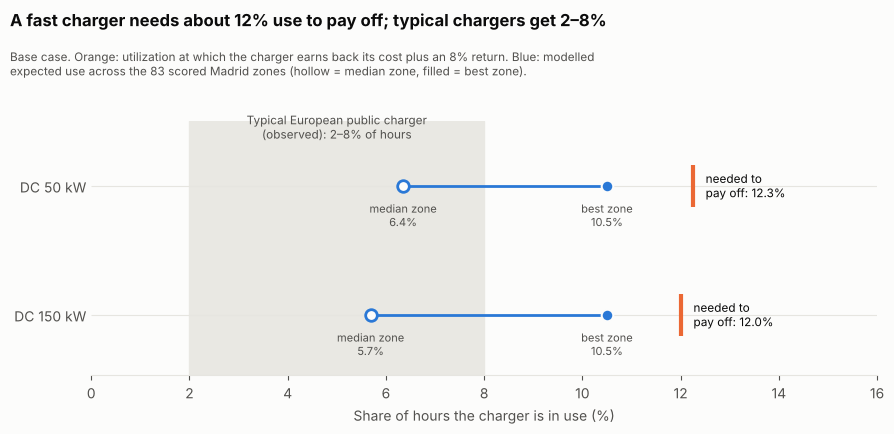

In [8]:
# Observed benchmark: European public chargers are in use 2-8% of hours (industry figures,
# summarised by motorpasion.com). This is the one utilization range in the chart that is not modelled.
OBS_LO, OBS_HI = 0.02, 0.08

base = det[det.case == "base"]
rows = [("DC150", "DC 150 kW"), ("DC50", "DC 50 kW")]

fig, ax = plt.subplots(figsize=(9, 4.4))
GAP = 1.6  # vertical spacing between rows
ax.axvspan(OBS_LO * 100, OBS_HI * 100, color="#e9e8e3", zorder=0)
ax.text((OBS_LO + OBS_HI) / 2 * 100, GAP + 0.55, "Typical European public charger\n(observed): 2–8% of hours",
        ha="center", va="bottom", fontsize=8.5, color=INK2)

for y, (ct, label) in enumerate(rows):
    y = y * GAP
    b = base[base.charger == ct]
    be = b.breakeven_util.iloc[0]
    med = b.utilization.median()
    best = b.utilization.max()
    best_name = b.loc[b.utilization.idxmax(), "name"]

    ax.hlines(y, 0, 16, color=GRID, lw=0.8, zorder=1)
    ax.plot([med * 100, best * 100], [y, y], color=BLUE, lw=2, zorder=2)
    ax.scatter(med * 100, y, s=70, facecolor=SURF, edgecolor=BLUE, linewidth=2, zorder=3)
    ax.scatter(best * 100, y, s=70, color=BLUE, edgecolor=SURF, linewidth=1.5, zorder=3)
    ax.vlines(be * 100, y - 0.26, y + 0.26, color=ORANGE, lw=3, zorder=4)

    ax.text(be * 100 + 0.25, y, f"needed to\npay off: {be:.1%}", ha="left", va="center",
            fontsize=8.5, color=INK)
    ax.text(med * 100, y - 0.2, f"median zone\n{med:.1%}", ha="center", va="top", fontsize=8, color=INK2)
    ax.text(best * 100, y - 0.2, f"best zone\n{best:.1%}", ha="center", va="top", fontsize=8, color=INK2)

ax.set_yticks([i * GAP for i in range(len(rows))], [l for _, l in rows])
ax.set_ylim(-0.75, GAP + 0.8)
ax.set_xlim(0, 16)
ax.set_xlabel("Share of hours the charger is in use (%)")
for s in ["left", "top", "right"]:
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.suptitle("A fast charger needs about 12% use to pay off; typical chargers get 2–8%",
             x=0.012, ha="left", y=0.975, fontsize=12, fontweight="bold")
fig.text(0.012, 0.885, "Base case. Orange: utilization at which the charger earns back its cost plus an 8% return. "
         "Blue: modelled\nexpected use across the 83 scored Madrid zones (hollow = median zone, filled = best zone).",
         ha="left", va="top", fontsize=8.5, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.84))
fig.savefig(MAPS / "breakeven_vs_utilization.png", dpi=200)
plt.show()

## 6 · Map: probability a DC 150 kW charger clears its cost of capital

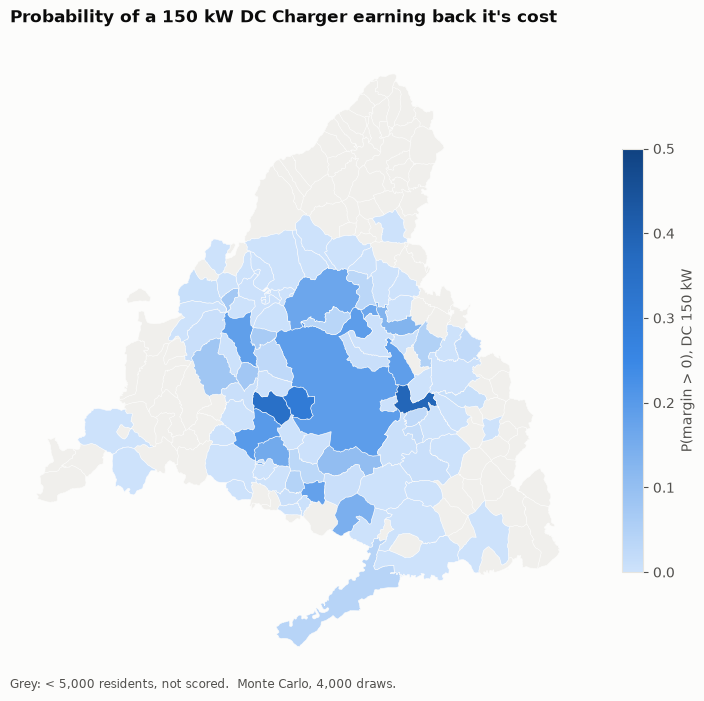

In [14]:
g = gpd.read_file(PROC / "features_municipal.gpkg")[["ine_code", "geometry"]]
g["ine_code"] = g.ine_code.astype(int)
gm = g.merge(profit[["ine_code", "dc150_p_profitable"]], on="ine_code", how="left")
fig, ax = plt.subplots(figsize=(7.5, 8))
gm[gm.dc150_p_profitable.isna()].plot(ax=ax, color=GRAY_MID, edgecolor=SURF, linewidth=0.4)
from matplotlib.colors import LinearSegmentedColormap
seq = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281"])
gm.dropna().plot(ax=ax, column="dc150_p_profitable", cmap=seq, vmin=0, vmax=0.5,
                 edgecolor=SURF, linewidth=0.4, legend=True,
                 legend_kwds={"label": "P(margin > 0), DC 150 kW", "shrink": 0.55})
ax.set_axis_off()
ax.set_title("Probability of a 150 kW DC Charger earning back it's cost")
ax.text(0, -0.02, "Grey: < 5,000 residents, not scored.  Monte Carlo, 4,000 draws.",
        transform=ax.transAxes, color=INK2, fontsize=8.5)
fig.tight_layout()
fig.savefig(MAPS / "map_p_profitable_dc150.png", dpi=200)
plt.show()

## 7 · Save Monte Carlo draws for notebook 06

In [10]:
import pickle
with open(PROC / "profit_mc_draws.pkl", "wb") as f:
    pickle.dump({"elig": elig, "draws": mc_draws}, f)
print("saved:", [p.name for p in [PROC / "profit_assumptions.csv", PROC / "profit_scenarios_long.csv",
                                  PROC / "profit_zones.csv", PROC / "profit_mc_draws.pkl"]])

saved: ['profit_assumptions.csv', 'profit_scenarios_long.csv', 'profit_zones.csv', 'profit_mc_draws.pkl']
